# SentinelAI — المرحلة ٣ (جزء ب): النماذج غير الخاضعة للإشراف (Unsupervised)

في هذا الملف نطبّق **٣ خوارزميات Unsupervised فقط** لاكتشاف الشذوذ (Anomaly Detection):

1. K-Means
2. DBSCAN
3. Isolation Forest

**لن ندرّب** شبكة CNN في هذا الملف — ستكون خطوة لاحقة منفصلة.

### فرق مهم عن نماذج المرحلة السابقة (Supervised)
هذه الخوارزميات **لا تستخدم عمود `Label` إطلاقاً أثناء التدريب** — هي تكتشف أنماطاً/تجمعات
في البيانات بنفسها فقط. نستخدم `Label` **بعد** التدريب فقط، لنتحقق: هل التجمعات
(Clusters) أو النقاط الشاذة (Anomalies) التي وجدتها الخوارزمية تتوافق فعلاً مع الهجمات
الحقيقية أم لا؟ ولأن لا تدريب فعلي على `Label`، لا مشكلة في التقييم على نفس البيانات
التي استُخدمت للـ Fitting (خلافاً للنماذج الخاضعة للإشراف حيث نفصل تدريب/اختبار لتفادي
الغش).

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")

PROCESSED_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42

**ماذا فعلنا ولماذا؟**
استوردنا الخوارزميات الثلاث (`KMeans`, `DBSCAN`, `IsolationForest`)، بالإضافة إلى
`PCA` و `NearestNeighbors` اللتين سنحتاجهما لاحقاً خصيصاً لضبط DBSCAN، ودوال `sklearn.metrics`
لتقييم مدى توافق النتائج مع `Label` الحقيقي.

In [2]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))

with open(os.path.join(PROCESSED_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = {int(k): v for k, v in json.load(f).items()}

print(f"X_train الكامل: {X_train.shape}")
print(f"عدد الفئات: {len(label_mapping)} -> {label_mapping}")

X_train الكامل: (908327, 77)
عدد الفئات: 11 -> {1: 'Benign', 2: 'Attack_2', 3: 'Attack_3', 4: 'Attack_4', 5: 'Attack_5', 6: 'Attack_6', 7: 'Attack_7', 8: 'Attack_8', 9: 'Attack_9', 10: 'Attack_10', 11: 'Attack_11'}


**ماذا فعلنا ولماذا؟**
حمّلنا بيانات التدريب المُقاسة (StandardScaler) نفسها المستخدمة في المرحلة ٢، حتى تكون
كل النماذج (Supervised و Unsupervised) مبنية على نفس التحضير للبيانات.

In [3]:
SAMPLE_SIZE = 15000

sample_X, _, sample_y, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

print(f"حجم العيّنة الممثّلة: {sample_X.shape[0]:,} صف من أصل {X_train.shape[0]:,}")
print("\nتوزيع الفئات داخل العيّنة:")
sample_dist = pd.Series(sample_y).value_counts().sort_index()
for code, count in sample_dist.items():
    print(f"  {code:>2} ({label_mapping[code]:<10}): {count:,}")

حجم العيّنة الممثّلة: 15,000 صف من أصل 908,327

توزيع الفئات داخل العيّنة:
   1 (Benign    ): 11,626
   2 (Attack_2  ): 464
   3 (Attack_3  ): 447
   4 (Attack_4  ): 1,642
   5 (Attack_5  ): 688
   6 (Attack_6  ): 100
   7 (Attack_7  ): 27
   8 (Attack_8  ): 4
   9 (Attack_9  ): 1
  10 (Attack_10 ): 1


**لماذا أخذنا عيّنة؟ (شرح الاختيار)**
خوارزمية `DBSCAN` تحسب المسافة بين كل نقطة وكل نقطة أخرى (تكلفة تقريباً `O(n²)`)، وعلى
بياناتنا الكاملة (~900 ألف صف × 77 عموداً) هذا يحتاج ذاكرة ووقتاً كبيرين جداً (قد يستغرق
ساعات أو يفشل بسبب الذاكرة). لذلك أخذنا عيّنة ممثّلة **Stratified** بحجم 15,000 صف — كبيرة
بما يكفي لتكون ذات معنى إحصائي، وصغيرة بما يكفي ليعمل DBSCAN خلال دقائق.

**ملاحظة عن الفئات النادرة جداً:** كما نرى أعلاه، بعض الفئات النادرة جداً في كل البيانات
(مثل `Attack_10` و `Attack_11` بأقل من 50 صفاً أصلاً) قد تظهر بعدد قليل جداً أو صفر في هذه
العيّنة — وهذا متوقّع ومقبول هنا، لأن هدف هذا الملف هو تقييم **قدرة الخوارزميات على تمييز
"طبيعي" مقابل "هجوم" بشكل عام (Anomaly Detection)**، وليس التمييز الدقيق بين كل نوع هجوم
على حدة (وهذا ما تفعله النماذج الخاضعة للإشراف في الملف السابق بدقة أعلى).

In [4]:
# 1 = Benign (طبيعي) بحسب التوثيق السابق، وأي رمز آخر يُعتبر هجوماً/شاذاً
is_attack_true = (sample_y != 1).astype(int)

attack_ratio = is_attack_true.mean()
print(f"نسبة الهجمات (الشذوذ) الحقيقية في العيّنة: {attack_ratio:.2%}")
print(f"نسبة الحركة الطبيعية: {1 - attack_ratio:.2%}")

نسبة الهجمات (الشذوذ) الحقيقية في العيّنة: 22.49%
نسبة الحركة الطبيعية: 77.51%


**ماذا فعلنا ولماذا؟**
حوّلنا `Label` (11 فئة) إلى هدف ثنائي بسيط: `0` = طبيعي (Benign) و `1` = هجوم/شاذ (أي فئة
أخرى). هذا هو المقياس الذي سنقارن به نتائج الخوارزميات الثلاث، لأن هذه الخوارزميات مصمّمة
أساساً لاكتشاف الشذوذ (نقطة طبيعية مقابل نقطة غير طبيعية)، وليس لتصنيف نوع الهجوم بالتحديد.

وقت التدريب: 0.6 ثانية
Accuracy: 0.5933 | Precision: 0.0960 | Recall: 0.0960 | F1: 0.0960


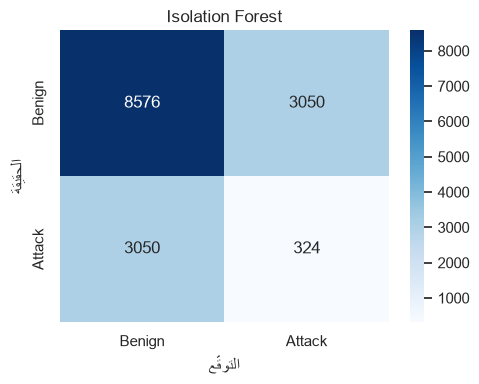

In [5]:
# نفترض هنا أننا نعرف تقريباً نسبة الهجمات المتوقعة (مثل معرفة تاريخية عامة عن الشبكة)
# ونمررها كـ contamination، بدل الاعتماد على القيمة الافتراضية 'auto' التي قد لا تناسب
# نسبة الشذوذ الحقيقية في بياناتنا (~22%، أعلى من المعتاد في مصادر بيانات أخرى).
start = time.time()
iso_model = IsolationForest(
    n_estimators=200,
    contamination=float(attack_ratio),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso_raw_pred = iso_model.fit_predict(sample_X)  # -1 = شاذ (هجوم)، 1 = طبيعي
iso_train_time = time.time() - start

iso_pred_attack = (iso_raw_pred == -1).astype(int)

precision, recall, f1, _ = precision_recall_fscore_support(
    is_attack_true, iso_pred_attack, average="binary", pos_label=1, zero_division=0
)
acc = accuracy_score(is_attack_true, iso_pred_attack)

print(f"وقت التدريب: {iso_train_time:.1f} ثانية")
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

cm = confusion_matrix(is_attack_true, iso_pred_attack)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel("التوقّع"); plt.ylabel("الحقيقة"); plt.title("Isolation Forest")
plt.tight_layout(); plt.show()

unsupervised_results = {}
unsupervised_results["Isolation Forest"] = {
    "Accuracy": acc, "Precision": precision, "Recall": recall, "F1-score": f1,
    "% نقاط عُدّت هجوماً": iso_pred_attack.mean() * 100,
    "وقت المعالجة (ث)": iso_train_time,
}

**ماذا فعلنا ولماذا؟**
`Isolation Forest` يعمل بفكرة: النقاط الشاذة "أسهل عزلاً" (تحتاج تقسيمات أقل في شجرة
عشوائية) من النقاط الطبيعية. النتيجة `-1` تعني نقطة شاذة اعتبرناها "هجوم"، و `1` تعني
طبيعية. حسبنا Precision/Recall/F1 بشكل ثنائي (Benign مقابل Attack) بالضبط كما طلبت،
ورسمنا مصفوفة التباس ثنائية بسيطة.

Cluster 0: 4,314 نقطة، نسبة الهجمات الحقيقية فيه = 16.57%
Cluster 1: 10,686 نقطة، نسبة الهجمات الحقيقية فيه = 24.88%

وقت التدريب: 0.2 ثانية
Accuracy: 0.7751 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


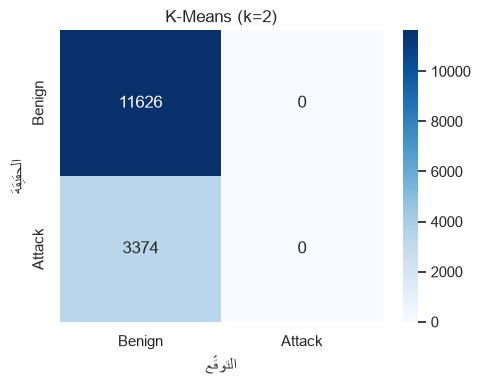


جدول تفصيلي: كل Cluster مقابل الفئات الحقيقية (11 فئة):
col_0  Attack_10  Attack_2  Attack_3  Attack_4  Attack_5  Attack_6  Attack_7  \
row_0                                                                          
0              0         0       223       408         2        69        13   
1              1       464       224      1234       686        31        14   

col_0  Attack_8  Attack_9  Benign  
row_0                              
0             0         0    3599  
1             4         1    8027  


In [6]:
start = time.time()
kmeans_model = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_model.fit_predict(sample_X)
kmeans_train_time = time.time() - start

# نحدّد أي Cluster هو "الهجوم" بحساب نسبة الهجمات الحقيقية داخل كل Cluster: لو أغلب
# نقاط الـ Cluster هجمات فعلياً (>50%)، نعتبر كل الـ Cluster "متوقَّع هجوم".
cluster_attack_ratio = {}
for cluster_id in np.unique(kmeans_labels):
    mask = kmeans_labels == cluster_id
    cluster_attack_ratio[cluster_id] = is_attack_true[mask].mean()
    print(f"Cluster {cluster_id}: {mask.sum():,} نقطة، نسبة الهجمات الحقيقية فيه = {cluster_attack_ratio[cluster_id]:.2%}")

attack_cluster_map = {c: (1 if r > 0.5 else 0) for c, r in cluster_attack_ratio.items()}
kmeans_pred_attack = np.array([attack_cluster_map[c] for c in kmeans_labels])

precision, recall, f1, _ = precision_recall_fscore_support(
    is_attack_true, kmeans_pred_attack, average="binary", pos_label=1, zero_division=0
)
acc = accuracy_score(is_attack_true, kmeans_pred_attack)
print(f"\nوقت التدريب: {kmeans_train_time:.1f} ثانية")
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

cm = confusion_matrix(is_attack_true, kmeans_pred_attack)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel("التوقّع"); plt.ylabel("الحقيقة"); plt.title("K-Means (k=2)")
plt.tight_layout(); plt.show()

print("\nجدول تفصيلي: كل Cluster مقابل الفئات الحقيقية (11 فئة):")
sample_y_named = pd.Series(sample_y).map(label_mapping)
print(pd.crosstab(kmeans_labels, sample_y_named))

unsupervised_results["K-Means"] = {
    "Accuracy": acc, "Precision": precision, "Recall": recall, "F1-score": f1,
    "% نقاط عُدّت هجوماً": kmeans_pred_attack.mean() * 100,
    "وقت المعالجة (ث)": kmeans_train_time,
}

**ماذا فعلنا ولماذا؟**
قسّمنا البيانات إلى `k=2` مجموعات (Clusters) — الأبسط لمطابقة الهدف الثنائي (طبيعي/هجوم)
المطلوب. لكن K-Means لا يعرف أصلاً أي Cluster هو "الهجوم" (الأرقام 0 و 1 اللتان ينتجهما
عشوائيتان بلا معنى)، لذلك **بعد** التجميع فقط نظرنا لكل Cluster وحسبنا: كم نسبة نقاطه
الحقيقية هجمات؟ لو أكثر من 50%، نسمّي الـ Cluster كله "متوقَّع هجوم". هذا ما يسمى
Cluster-to-label mapping، وهو أسلوب قياسي لتقييم التجميع مقابل تصنيف حقيقي. الجدول
التفصيلي (Crosstab) يوضّح بدقة كيف توزّعت كل الفئات (وليس فقط طبيعي/هجوم) على الـ Clusters
الاثنين.

نسبة التباين المحفوظة بعد اختزال الأبعاد إلى 10: 80.68%
قيمة eps المختارة (النسبة المئوية 90 لمسافة أقرب 10 جيران): 0.4619


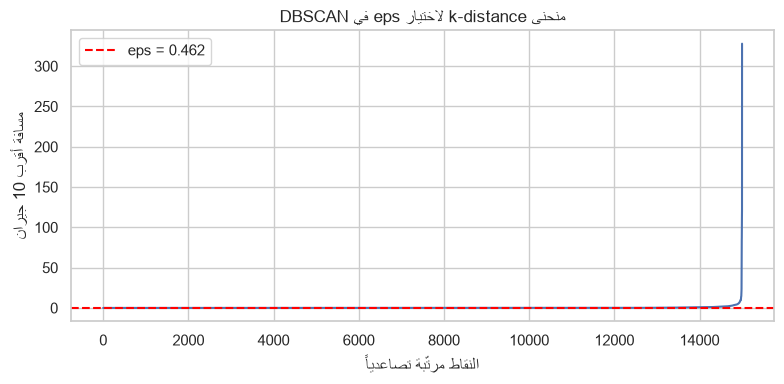

In [7]:
# DBSCAN يعاني من "لعنة الأبعاد العالية" (Curse of Dimensionality): في 77 بعداً تصبح كل
# النقاط متباعدة عن بعضها بشكل متقارب، فيصعب تعريف "الكثافة". لذلك نختزل الأبعاد إلى 10
# مكوّنات رئيسية (PCA) قبل تطبيق DBSCAN فقط (لا نستخدم هذا الاختزال في باقي النماذج).
pca_dbscan = PCA(n_components=10, random_state=RANDOM_STATE)
sample_X_pca = pca_dbscan.fit_transform(sample_X)
print(f"نسبة التباين المحفوظة بعد اختزال الأبعاد إلى 10: {pca_dbscan.explained_variance_ratio_.sum():.2%}")

MIN_SAMPLES = 10
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1).fit(sample_X_pca)
distances, _ = neighbors.kneighbors(sample_X_pca)
k_distances = np.sort(distances[:, -1])

eps_value = np.percentile(k_distances, 90)
print(f"قيمة eps المختارة (النسبة المئوية 90 لمسافة أقرب {MIN_SAMPLES} جيران): {eps_value:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.axhline(eps_value, color="red", linestyle="--", label=f"eps = {eps_value:.3f}")
plt.xlabel("النقاط مرتّبة تصاعدياً")
plt.ylabel(f"مسافة أقرب {MIN_SAMPLES} جيران")
plt.title("منحنى k-distance لاختيار eps في DBSCAN")
plt.legend()
plt.tight_layout()
plt.show()

**ماذا فعلنا ولماذا؟ (كيف اخترنا eps و min_samples)**
`DBSCAN` يحتاج معاملين أساسيين: `eps` (نصف قطر الجوار) و `min_samples` (أقل عدد نقاط
لاعتبار منطقة "كثيفة"). اخترنا `min_samples=10` كقيمة معقولة (القاعدة الشائعة `2×الأبعاد`
غير عملية هنا لأنها كانت ستعطي رقماً كبيراً جداً بالنسبة لحجم عيّنتنا). لاختيار `eps`
بطريقة منهجية بدل التخمين: حسبنا لكل نقطة مسافتها عن أقرب 10 جيران، رتّبنا هذه المسافات
تصاعدياً، ورسمناها (منحنى k-distance). اخترنا `eps` عند النسبة المئوية 90 من هذا المنحنى
(قريب من "الركبة" حيث تبدأ المسافات بالقفز فجأة) — وهي طريقة معروفة ومعيارية لضبط DBSCAN
دون الحاجة لتجربة قيم عشوائية يدوياً.

وقت التدريب: 0.3 ثانية
عدد المجموعات (Clusters) المكتشفة (بدون النقاط الشاذة): 58
نسبة النقاط المصنَّفة كـ Noise (شاذة): 8.71%
Accuracy: 0.7016 | Precision: 0.0781 | Recall: 0.0302 | F1: 0.0436


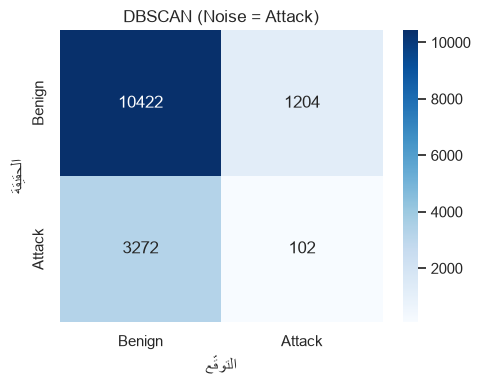

In [8]:
start = time.time()
dbscan_model = DBSCAN(eps=eps_value, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_labels = dbscan_model.fit_predict(sample_X_pca)
dbscan_train_time = time.time() - start

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_ratio = (dbscan_labels == -1).mean()
print(f"وقت التدريب: {dbscan_train_time:.1f} ثانية")
print(f"عدد المجموعات (Clusters) المكتشفة (بدون النقاط الشاذة): {n_clusters}")
print(f"نسبة النقاط المصنَّفة كـ Noise (شاذة): {noise_ratio:.2%}")

# النقاط الشاذة (-1) في DBSCAN هي بطبيعتها أقرب مفهوم لـ "anomaly" — نعتبرها هجمات متوقَّعة.
dbscan_pred_attack = (dbscan_labels == -1).astype(int)

precision, recall, f1, _ = precision_recall_fscore_support(
    is_attack_true, dbscan_pred_attack, average="binary", pos_label=1, zero_division=0
)
acc = accuracy_score(is_attack_true, dbscan_pred_attack)
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

cm = confusion_matrix(is_attack_true, dbscan_pred_attack)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Attack"], yticklabels=["Benign", "Attack"])
plt.xlabel("التوقّع"); plt.ylabel("الحقيقة"); plt.title("DBSCAN (Noise = Attack)")
plt.tight_layout(); plt.show()

unsupervised_results["DBSCAN"] = {
    "Accuracy": acc, "Precision": precision, "Recall": recall, "F1-score": f1,
    "% نقاط عُدّت هجوماً": dbscan_pred_attack.mean() * 100,
    "وقت المعالجة (ث)": dbscan_train_time,
}

**ماذا فعلنا ولماذا؟**
طبّقنا DBSCAN على النسخة المختزلة (10 أبعاد) من العيّنة. الميزة الفريدة في DBSCAN أنه
لا يجبر كل نقطة على الانضمام لمجموعة — أي نقطة لا تقع في منطقة كثيفة كافية تُصنَّف
`-1` (Noise/شاذة). استغللنا هذا مباشرة: اعتبرنا كل نقطة `Noise` هجوماً متوقَّعاً (هذا هو
التفسير الطبيعي لـ DBSCAN كأداة كشف شذوذ)، دون الحاجة لخطوة "تصويت الأغلبية" التي
استخدمناها مع K-Means.

In [9]:
comparison_df = pd.DataFrame(unsupervised_results).T
comparison_df = comparison_df[
    ["Accuracy", "Precision", "Recall", "F1-score", "% نقاط عُدّت هجوماً", "وقت المعالجة (ث)"]
]
comparison_df = comparison_df.sort_values("F1-score", ascending=False)

print(f"النسبة الحقيقية للهجمات في العيّنة (للمقارنة): {attack_ratio:.2%}\n")
print("جدول مقارنة النماذج الثلاثة (Unsupervised):")
print(comparison_df.round(4).to_string())

comparison_df.round(4).to_csv(os.path.join(MODELS_DIR, "unsupervised_comparison.csv"))

النسبة الحقيقية للهجمات في العيّنة (للمقارنة): 22.49%

جدول مقارنة النماذج الثلاثة (Unsupervised):
                  Accuracy  Precision  Recall  F1-score  % نقاط عُدّت هجوماً  وقت المعالجة (ث)
Isolation Forest    0.5933     0.0960  0.0960    0.0960              22.4933            0.6097
DBSCAN              0.7016     0.0781  0.0302    0.0436               8.7067            0.3412
K-Means             0.7751     0.0000  0.0000    0.0000               0.0000            0.1761


**ماذا فعلنا ولماذا؟**
جمعنا نتائج الخوارزميات الثلاث (كلها مُقاسة بنفس الطريقة الثنائية: طبيعي مقابل هجوم) في
جدول واحد، ورتّبناه حسب F1-score. أضفنا أيضاً عمود "% نقاط عُدّت هجوماً" ليتضح هل الخوارزمية
متحفّظة جداً (تعلّم القليل كهجمات) أو متساهلة جداً (تعلّم الكثير كهجمات) مقارنة بالنسبة
الحقيقية المطبوعة أعلاه. حفظنا الجدول في `models/unsupervised_comparison.csv`.

In [10]:
joblib.dump(iso_model, os.path.join(MODELS_DIR, "isolation_forest.joblib"))
joblib.dump(kmeans_model, os.path.join(MODELS_DIR, "kmeans.joblib"))
joblib.dump(dbscan_model, os.path.join(MODELS_DIR, "dbscan.joblib"))
joblib.dump(pca_dbscan, os.path.join(MODELS_DIR, "dbscan_pca.joblib"))

for fname in ["isolation_forest.joblib", "kmeans.joblib", "dbscan.joblib",
              "dbscan_pca.joblib", "unsupervised_comparison.csv"]:
    path = os.path.join(MODELS_DIR, fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"تم حفظ {fname} ({size_kb:.1f} KB)")

تم حفظ isolation_forest.joblib (1754.3 KB)
تم حفظ kmeans.joblib (60.5 KB)
تم حفظ dbscan.joblib (1278.0 KB)
تم حفظ dbscan_pca.joblib (7.8 KB)
تم حفظ unsupervised_comparison.csv (0.2 KB)


**ماذا فعلنا ولماذا؟**
حفظنا الخوارزميات الثلاث المدرَّبة، بالإضافة إلى `PCA` المستخدم مع DBSCAN (ضروري لأن أي
استخدام مستقبلي لنموذج DBSCAN المحفوظ يجب أن يمرّ بنفس اختزال الأبعاد أولاً). لاحظ أن
DBSCAN تحديداً **لا يملك دالة `.predict()`** للبيانات الجديدة أصلاً (يعمل فقط على البيانات
التي دُرِّب عليها)، لذلك حفظه هنا هو للتوثيق والرجوع إليه لاحقاً وليس للاستخدام المباشر
على بيانات جديدة كما يمكن فعله مع K-Means أو Isolation Forest.

## الخلاصة

طبّقنا الخوارزميات الثلاث غير الخاضعة للإشراف على عيّنة ممثّلة (15,000 صف) من بيانات
التدريب، وقيّمنا كل واحدة بمقارنة نتائجها (هجوم/طبيعي) بالتصنيف الحقيقي:

- **Isolation Forest**: نستخدم `-1`/`1` مباشرة كتوقّع هجوم/طبيعي.
- **K-Means**: قسّمنا لـ 2 مجموعات، وحدّدنا أي مجموعة "هجوم" بأغلبية نقاطها الحقيقية.
- **DBSCAN**: اعتبرنا النقاط "الشاذة" (Noise) هجمات متوقَّعة، بعد اختزال الأبعاد بـ PCA.

النتائج محفوظة في `models/` (النماذج الثلاثة + جدول المقارنة). كما هو متوقّع، هذه
الخوارزميات (بدون رؤية أي تصنيف أثناء التدريب) عادة أضعف من النماذج الخاضعة للإشراف في
الملف السابق — لكنها مفيدة لاكتشاف أنماط شاذة **جديدة** لم يرها أي نموذج من قبل.

**لم يتم بعد:** شبكة CNN — ستكون الخطوة اللاحقة.